### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: **Bing-Yun Wu**
*   Your **student number**: **1012861039**



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [7]:
pip install python-Levenshtein

In [8]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [9]:
### YOUR CODE HERE ###
import numpy as np
import matplotlib.pyplot as plt

countries_list = pd.read_csv(countries_list_url, header=None, names=['Countries'])
raw_data['population_historical'] = raw_data['population_historical'].astype(float)

df_selected = raw_data[(raw_data['year'] > 1900) & (raw_data['entity'].isin(countries_list['Countries']))].copy()
X_table = df_selected.pivot(index='entity', columns='year', values='population_historical')
X_table_cleaned = X_table.dropna(axis=0)
display(X_table_cleaned)

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,2733334.0,2765603.0,2796321.0,2827377.0,2858773.0,2890514.0,2922603.0,2955044.0,2985778.0,3014767.0,...,30254080.0,30573968.0,30765719.0,30565331.0,29807591.0,28938096.0,28444080.0,28237830.0,28213015.0,28300861.0
Vietnam,12199511.0,12734169.0,13412346.0,14126641.0,14878976.0,15671378.0,16505981.0,17385031.0,18088666.0,18608564.0,...,91679582.0,92823254.0,94000115.0,95176978.0,96237319.0,97173778.0,98079196.0,98935101.0,99680656.0,100352189.0
Yemen,2984894.0,3006808.0,3033193.0,3059809.0,3086657.0,3113742.0,3141063.0,3168624.0,3196638.0,3225110.0,...,30226311.0,31159378.0,32109023.0,33090923.0,34085181.0,35111416.0,36134867.0,37140234.0,38222878.0,39390800.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**
    * **For Belgium, Bosnia and Herzegovina, and Latvia, the figures show that the populations gradually deviate further from the mean population over time. A similar pattern is observed for Benin and the United Arab Emirates before approximately 1960. After that period, however, their populations gradually converge toward the mean population. For Japan, the figure indicates that the population gradually diverges away from the mean population before 1950; however, it begins to converge toward the mean population after 1950.**
    * **The sign of the standardized value indicates whether country’s population is above or below than the mean population. For positive values, the upward curve means that the country’s population is diverging further from the mean population, whereas the downward curve means that it is converging toward the mean population. For negative values, the interpretation is reversed. The upward curve indicates convergence toward the mean, while the downward curve indicates divergence away from the mean.**

In [10]:
def population_plots (df, countries):
    fig_height = len(countries) // 3 + 1

    plt.figure(figsize=(11, 3.5*fig_height))
    for country in countries:
        plt.subplot(fig_height, 3, countries.index(country) + 1)
        plt.plot(df.loc[country, :])
        plt.plot(df.mean(axis=0), 'r--', label='Mean')
        plt.xlabel('Year')
        plt.ylabel('Population / Standardized Poplation')
        plt.legend()
        plt.title(country)

    plt.tight_layout()
    plt.show()
    print("\n")

    return None

Closest countries to my first name:


,Country,distance
21,Benin,5
19,Belgium,5
5,Angola,6




Population Time Series:


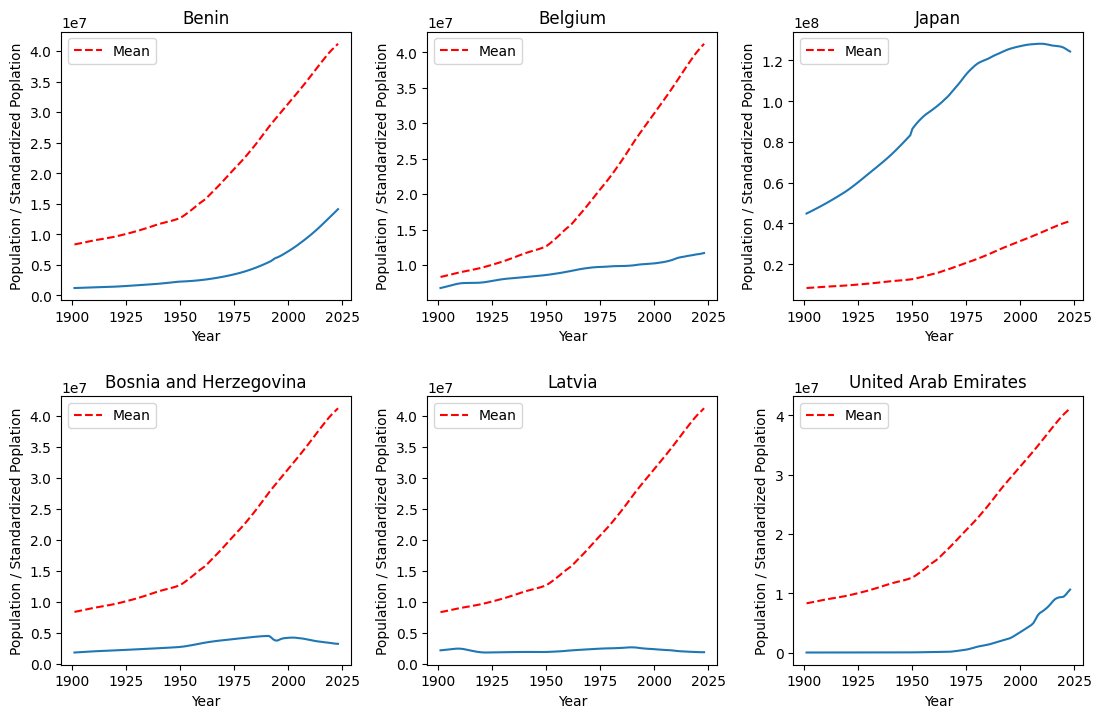



Standardized Population Time Series:


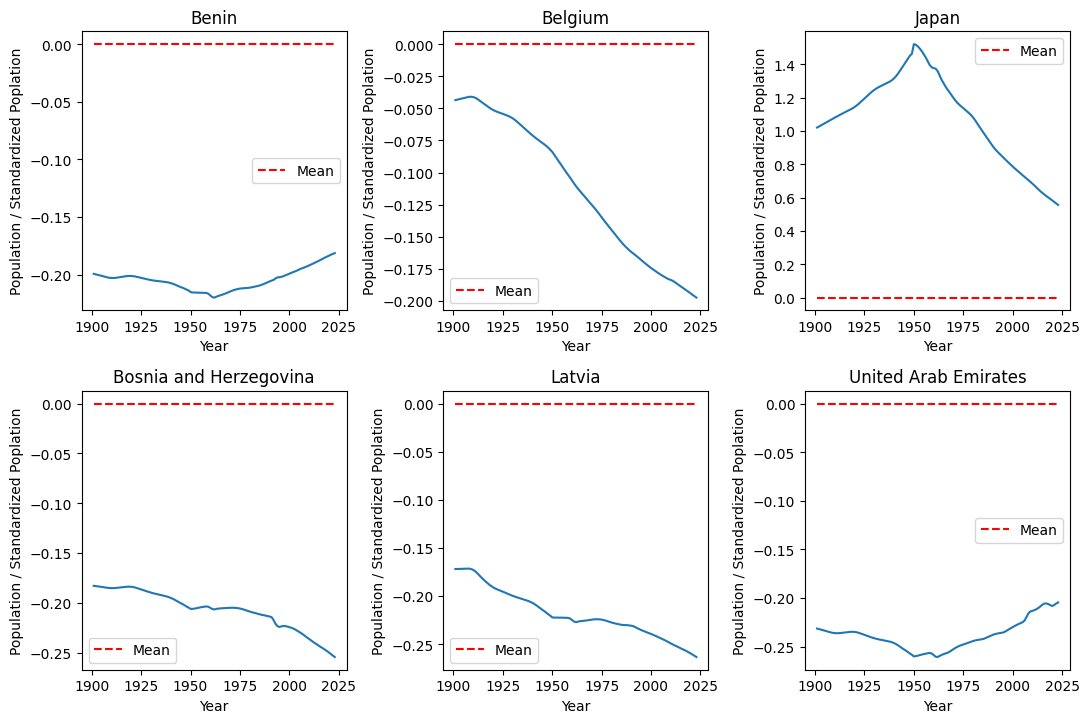

In [11]:
### YOUR CODE HERE ###
from sklearn.preprocessing import StandardScaler
import Levenshtein

# Standardize the dataset for each year
scaler = StandardScaler()
X_std = X_table_cleaned.copy()

X_std = scaler.fit_transform(X_std)
X_std = pd.DataFrame(X_std, columns=X_table_cleaned.columns, index=X_table_cleaned.index)

# Closest countries to my first name
dist = []
my_first_name = 'Bing-Yun'

for country in countries_list['Countries']:
    dist_calc = Levenshtein.distance(country, my_first_name)
    dist.append({
        'Country': country,
        'distance': dist_calc
    })

df_dist = pd.DataFrame(dist)
dist_sorted = df_dist.sort_values(by='distance', ascending=True).head(3)
print("Closest countries to my first name:")
display(dist_sorted)
print("\n")

# Plot original and standardized time series figures
candidate_countries = dist_sorted['Country'].tolist()[0:2] + ['Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']
print("Population Time Series:")
population_plots(X_table_cleaned, candidate_countries)
print("Standardized Population Time Series:")
population_plots(X_std, candidate_countries)